In [57]:
using LinearAlgebra
using Plots
using QuadGK
using FastGaussQuadrature
using LaTeXStrings
pgfplotsx() # pgfplotsx() or gr()
default(
    fontfamily = "Computer Modern",
    tickfont   = font(15, "Computer Modern"),
    guidefont  = font(15, "Computer Modern"),
    legendfont = font(15, "Computer Modern"),
    lw = 2,
    grid = :on,
    gridalpha = 0.3,
    size = (500, 400),
    legend = :topright,
    framestyle = :box,
    color_palette = palette(:tab10)
)
const address = "/Users/johnreeg/Documents/Repositories/Maris-Tandy/images/";

In [58]:
# Constants
Nf = 4.0
m = 0.0037
w = 0.16
D = 0.93
Lambda2 = 1e6
epsilon2 = 1e-4
Lambda_PV = 2e2
Lambda_QCD = 0.234
gamma_m = 0.48 # 12/(33 - 2 * Nf) = 0.48
mu = 19.0
Z_2 = 1
Z_4m = 0.7 * m

# Integration Grids
x, w_x = gausslegendre(350)
z, w_z = gausschebyshevu(40) # Chebyshev second kind
t = 0.5 * (log(Lambda2) - log(epsilon2)) * x .+ 0.5 * (log(Lambda2) + log(epsilon2))
w_t = 0.5 * (log(Lambda2) - log(epsilon2)) * w_x

# Initial Vectors
A = 1.6 * ones(length(t))
B = (m + 1e-3) * ones(length(t))

# Index next to p^2 = mu^2
mu_i = argmin(abs.(t .- 2*log(mu)));

In [59]:
# Dot Products
pk(p, q, z) = p^2 - p*q*z
qk(p, q, z) = p*q*z - q^2
k2(p, q, z) = p^2 + q^2 - 2*p*q*z

# Stephan called them alpha(k^2)
F_UV(k2) = 2pi * gamma_m * (1 - exp(-k2)) / log(exp(2) - 1 + (1 + k2 / Lambda_QCD^2)^2)
G(k2) = D/w^6 * pi * k2^2 * exp(-k2 / w^2) + F_UV(k2)

# Angular Integrals over z = cos(psi)
function z_intA(p, q)
    K2 = k2.(p, q, z)
    integrand = @. w_z * ( p*q*z + 2*pk(p, q, z)*qk(p, q, z)/K2 ) * G(K2) / K2 # * Lambda_PV^2 / (K2 + Lambda_PV^2)
    return sum(integrand)
end

function z_intB(p, q)
    K2 = k2.(p, q, z)
    integrand = @. w_z * G(K2) / K2 # * Lambda_PV^2 / (K2 + Lambda_PV^2)
    return sum(integrand)
end;

In [60]:
# Final Radial Integrals
function Sigma_A(p2, A, B, Z_2)
    integrand = @. w_t * exp(2*t) * A / (exp(t) * A^2 + B^2) * z_intA(sqrt(Complex(p2)), exp(t/2))
    return Z_2^2 * 16pi/(3*(2pi)^3 * p2) * sum(integrand)
end

function Sigma_B(p2, A, B, Z_2)
    integrand = @. w_t * exp(2*t) * B / (exp(t) * A^2 + B^2) * z_intB(sqrt(Complex(p2)), exp(t/2))
    return Z_2^2 * 16pi/(2pi)^3 * sum(integrand)
end;

In [61]:
# Iteration Step Function
function update(A, B, Z_2, Z_4m)
    A_int = Z_2 .+ Sigma_A.(exp.(t), Ref(A), Ref(B), Z_2)
    B_int = Z_4m .+ Sigma_B.(exp.(t), Ref(A), Ref(B), Z_2)
    max_A = maximum(abs.(A .- A_int))
    max_B = maximum(abs.(B .- B_int))
    Z_2  = 1 - Sigma_A(mu^2, A, B, Z_2)
    Z_4m = m - Sigma_B(mu^2, A, B, Z_2)
    # alpha = 0.5
    # return alpha .* A_int .+ (1-alpha) .* A, alpha .* B_int .+ (1-alpha) .* B, max(max_A, max_B)
    return A_int, B_int, Z_2, Z_4m, max(max_A, max_B)
end;

In [62]:
# Iteration Loop
for i in 1:200
    A, B, Z_2, Z_4m, max_error = update(A, B, Z_2, Z_4m)
    if max_error < 1e-6
        println("Finished: i = ", i)
        break
    end
    if i == 200
        throw(error("Failed: max_error = ", max_error))
    end
    println("i = ", i)
end

i = 1
i = 2
i = 3
i = 4
i = 5
i = 6
i = 7
i = 8
i = 9
i = 10
i = 11
i = 12
i = 13
i = 14
i = 15
i = 16
i = 17
i = 18
i = 19
i = 20
i = 21
i = 22
i = 23
i = 24
i = 25
i = 26
i = 27
i = 28
i = 29
i = 30
i = 31
i = 32
i = 33
i = 34
i = 35
i = 36
i = 37
i = 38
i = 39
i = 40
i = 41
i = 42
i = 43
i = 44
i = 45
i = 46
i = 47
i = 48
i = 49
i = 50
i = 51
i = 52
i = 53
i = 54
i = 55
i = 56
i = 57
i = 58
i = 59
i = 60
Finished: i = 61


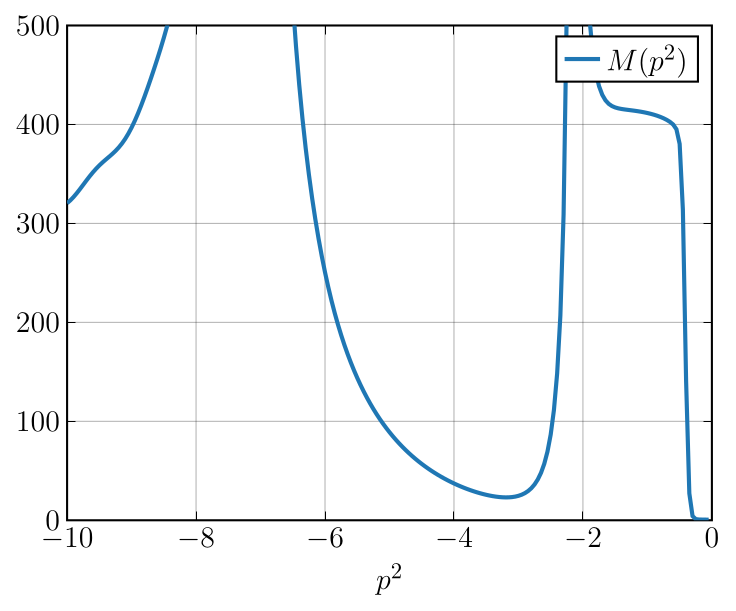

In [63]:
p2_imag = -10:0.05:0
A_imag = Z_2 .+ Sigma_A.(p2_imag, Ref(A), Ref(B), Z_2)
B_imag = Z_4m .+ Sigma_B.(p2_imag, Ref(A), Ref(B), Z_2)
plot(p2_imag, abs.(B_imag ./ A_imag), xlims = (-10, 0), ylims = (0, 500), label = L"M(p^2)", xlabel = L"p^2") # \; \left[\mathrm{GeV}^2\right]
# plot!(p2_imag, real.(B_imag ./ A_imag), label = "real")
# plot!(p2_imag, imag.(B_imag ./ A_imag), label = "imag")
# savefig("Imag.pdf")
# plot!()